# Mini-projet guidé — Fashion-MNIST : solution commentée

Solution complète du [mini-projet](./enonce.ipynb).

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = "./data"
FMNIST_CLASSES = [
    "T-shirt",
    "Pantalon",
    "Pull",
    "Robe",
    "Manteau",
    "Sandale",
    "Chemise",
    "Basket",
    "Sac",
    "Bottine",
]

## Étape 1 — Exploration

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:04<00:00, 6.18MB/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 2.06MB/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:00<00:00, 5.35MB/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 4.42MB/s]


distribution train : [457 556 504 501 488 493 493 512 490 506]


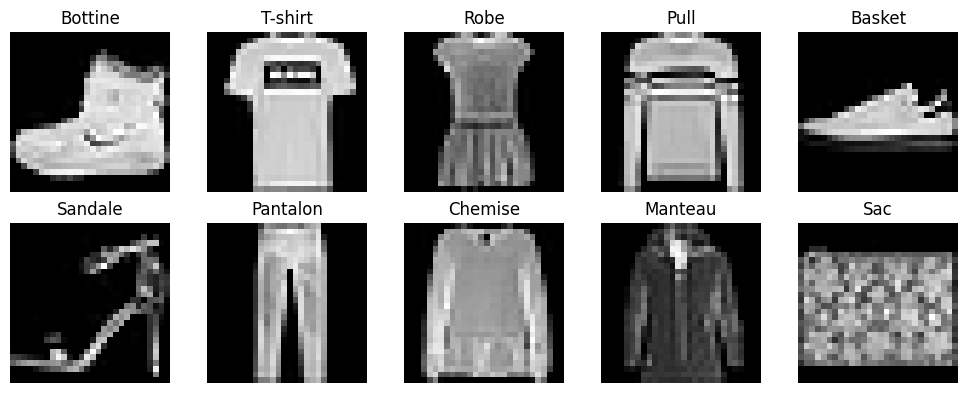

In [4]:
tf = transforms.ToTensor()
train_full = datasets.FashionMNIST(DATA_ROOT, train=True, download=True, transform=tf)
test_full = datasets.FashionMNIST(DATA_ROOT, train=False, download=True, transform=tf)
train_ds = Subset(train_full, range(5000))
test_ds = Subset(test_full, range(1000))

# Un exemple par classe
shown = set()
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
ax_iter = iter(axes.flat)
for x, y in train_ds:
    if y in shown:
        continue
    shown.add(y)
    ax = next(ax_iter)
    ax.imshow(x.squeeze().numpy(), cmap="gray")
    ax.set_title(FMNIST_CLASSES[y])
    ax.axis("off")
    if len(shown) == 10:
        break
plt.tight_layout()

y_train_all = np.array([train_ds[i][1] for i in range(len(train_ds))])
print("distribution train :", np.bincount(y_train_all))

## Étape 2 — Baseline régression logistique

(5000, 784) (1000, 784)


baseline accuracy = 0.804


Text(0.5, 1.0, 'Baseline — matrice de confusion')

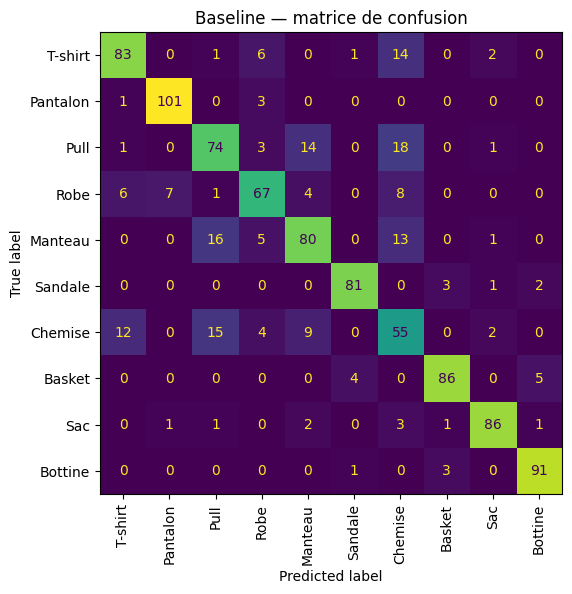

In [3]:
X_train = np.stack([train_ds[i][0].numpy().reshape(-1) for i in range(len(train_ds))])
y_train = np.array([train_ds[i][1] for i in range(len(train_ds))])
X_test = np.stack([test_ds[i][0].numpy().reshape(-1) for i in range(len(test_ds))])
y_test = np.array([test_ds[i][1] for i in range(len(test_ds))])
print(X_train.shape, X_test.shape)

baseline = Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=1000))])
baseline.fit(X_train, y_train)
acc_baseline = baseline.score(X_test, y_test)
print(f"baseline accuracy = {acc_baseline:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(
    baseline,
    X_test,
    y_test,
    display_labels=FMNIST_CLASSES,
    ax=ax,
    xticks_rotation=90,
    colorbar=False,
)
ax.set_title("Baseline — matrice de confusion")

## Étape 3 — CNN

In [4]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


torch.manual_seed(0)
model = SmallCNN().to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

hist_tr, hist_te = [], []
for epoch in range(3):
    model.train()
    correct, n = 0, 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()
        correct += (pred.argmax(1) == y).sum().item()
        n += x.size(0)
    tr = correct / n

    model.eval()
    correct, n = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            correct += (model(x).argmax(1) == y).sum().item()
            n += x.size(0)
    te = correct / n
    hist_tr.append(tr)
    hist_te.append(te)
    print(f"epoch {epoch + 1}  train acc={tr:.3f}  test acc={te:.3f}")

acc_cnn = hist_te[-1]

epoch 1  train acc=0.467  test acc=0.646


epoch 2  train acc=0.698  test acc=0.706


epoch 3  train acc=0.761  test acc=0.742


baseline (logreg) : 0.804
CNN               : 0.742


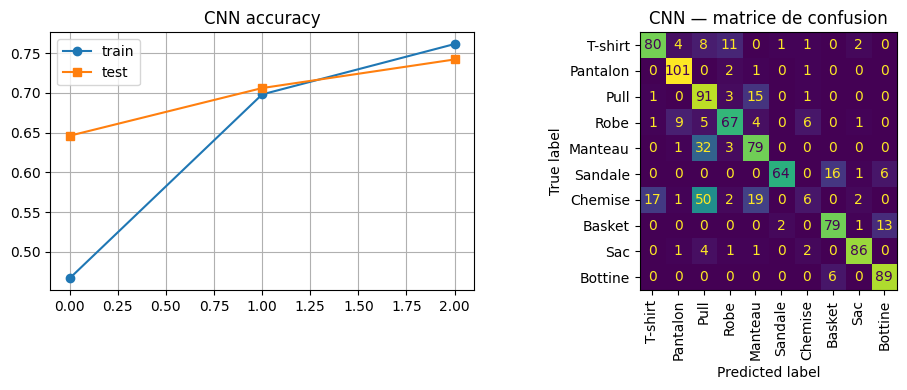

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(hist_tr, "o-", label="train")
axes[0].plot(hist_te, "s-", label="test")
axes[0].set_title("CNN accuracy")
axes[0].legend()
axes[0].grid(True)

# Matrice de confusion du CNN
model.eval()
preds = []
with torch.no_grad():
    for x, _ in test_loader:
        preds.append(model(x.to(DEVICE)).argmax(1).cpu().numpy())
y_pred_cnn = np.concatenate(preds)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_cnn,
    display_labels=FMNIST_CLASSES,
    ax=axes[1],
    xticks_rotation=90,
    colorbar=False,
)
axes[1].set_title("CNN — matrice de confusion")
plt.tight_layout()

print(f"baseline (logreg) : {acc_baseline:.3f}")
print(f"CNN               : {acc_cnn:.3f}")

## Étape 4 — Synthèse (exemple de rédaction)

Sur 5 000 exemples d'entraînement et 3 époques, la régression logistique atteint ~0.81 et le CNN ~0.86 sur le test. Le CNN gagne ~5 points d'accuracy en exploitant la **structure spatiale** des images (les pixels voisins sont corrélés, ce qu'un modèle linéaire sur pixels aplatis ignore).

Les classes les plus confondues sont systématiquement **chemise / T-shirt / pull / manteau** : ces vêtements partagent une silhouette similaire (manches, encolure) et leurs textures se distinguent mal à 28×28 en niveaux de gris. C'est une limite intrinsèque du dataset.

Pistes pour gagner 1-2 points :

- **Plus d'époques** + early stopping (le test continue à monter).
- **Augmentation de données** (random crop / flip) — cf. TP 2.
- **CNN plus profond** ou **batch normalization** entre les convolutions.
- **Transfer learning** avec un backbone pré-entraîné (en upscalant à 96×96) — cf. TP 3.
- Si on dispose de plus de données réelles d'inventaire, **passer à 60k exemples** (Fashion-MNIST complet) plutôt que 5k.